# Chapter 12 Python Lab  
## Constrained Optimization and Lagrange Multipliers

This lab accompanies **Chapter 12: Constrained Optimization and Lagrange Multipliers**.

In unconstrained optimization, we search for critical points by solving

$$
\nabla f=\mathbf 0.
$$

In constrained optimization, the feasible points must satisfy one or more equations or inequalities.  
For an equality constraint

$$
g(x,y)=c,
$$

the Lagrange multiplier condition is

$$
\nabla f(x,y)=\lambda \nabla g(x,y).
$$

Geometrically, at a constrained extremum, the level curve of $f$ is tangent to the constraint curve.  
Equivalently, the gradient of $f$ is normal to the constraint curve, just as $\nabla g$ is.

This lab uses Python to explore:

- constrained extrema by parameterization;
- Lagrange multiplier equations;
- geometry of tangent level curves;
- constrained extrema on circles, ellipses, planes, and spheres;
- boundary checks for closed regions;
- projected gradient methods;
- penalty methods;
- and data-science examples of constrained optimization.

Only `numpy` and `matplotlib` are required.

## Learning goals

By the end of this lab, you should be able to:

1. distinguish unconstrained and constrained optimization;
2. visualize feasible sets given by equations and inequalities;
3. solve simple constrained problems by parameterization;
4. solve equality-constrained problems using Lagrange multipliers;
5. interpret the condition $\nabla f=\lambda\nabla g$ geometrically;
6. handle boundary and corner checks for inequality constraints;
7. solve selected problems with multiple constraints;
8. compare analytic solutions with numerical search;
9. use projected gradient methods for constrained motion;
10. understand penalty methods as an approximate constrained optimization technique.

## Source note

This notebook was generated from the uploaded Chapter 12 QMD file.  
The extracted early headings from the source file include:

- Learning objectives
- 12.1 What makes an optimization problem constrained?
- The optimization question has two parts
- 12.2 The geometry of tangency
- Extremal points for f=2x+6y on x^2+y^2=10.
- 12.3 The method of Lagrange multipliers: one constraint
- Regularity assumption
- Algorithm 12.1: equality-constrained extrema
- 12.4 A first worked example: a linear objective on a circle
- 12.5 Why $\nabla f=\lambda \nabla g$ means no feasible first-order change
- 12.6 Distance problems
- Worked example 12.2: closest point on a parabola

## 0. Setup

Run this cell first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.set_printoptions(precision=6, suppress=True)

def norm(v):
    return np.linalg.norm(v)

def unit(v, tol=1e-12):
    v = np.asarray(v, dtype=float)
    n = norm(v)
    if n < tol:
        raise ValueError("The zero vector has no unit direction.")
    return v / n

def make_grid(xmin=-3, xmax=3, ymin=-3, ymax=3, n=300):
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    X, Y = np.meshgrid(x, y)
    return x, y, X, Y

def safe_eval_2d(f, X, Y):
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        Z = f(X, Y)
    return np.asarray(Z, dtype=float)

def make_3d_axes(title=None, elev=28, azim=45):
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    if title:
        ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)
    return fig, ax

def plot_contours_with_constraint(f_xy, g_xy, c=0.0,
                                  xmin=-3, xmax=3, ymin=-3, ymax=3,
                                  levels=20, title="Contours with constraint",
                                  points=None):
    x, y, X, Y = make_grid(xmin, xmax, ymin, ymax, n=400)
    Z = safe_eval_2d(f_xy, X, Y)
    G = safe_eval_2d(g_xy, X, Y)
    fig, ax = plt.subplots(figsize=(7, 6))
    cs = ax.contour(X, Y, Z, levels=levels)
    ax.clabel(cs, inline=True, fontsize=8)
    ax.contour(X, Y, G, levels=[c], linewidths=3)
    if points is not None:
        points = np.asarray(points)
        ax.scatter(points[:,0], points[:,1], s=90)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)
    plt.show()

def finite_gradient(f, p, h=1e-5):
    p = np.asarray(p, dtype=float)
    grad = np.zeros_like(p)
    for j in range(len(p)):
        step = np.zeros_like(p)
        step[j] = h
        grad[j] = (f(p + step) - f(p - step)) / (2*h)
    return grad

def finite_jacobian(F, p, h=1e-5):
    p = np.asarray(p, dtype=float)
    y0 = np.asarray(F(p), dtype=float)
    J = np.zeros((len(y0), len(p)))
    for j in range(len(p)):
        step = np.zeros_like(p)
        step[j] = h
        J[:, j] = (np.asarray(F(p + step)) - np.asarray(F(p - step))) / (2*h)
    return J

def newton_system(F, J, x0, steps=20, tol=1e-12, verbose=False):
    """
    Newton's method for F(x)=0 with explicit Jacobian J.
    """
    x = np.asarray(x0, dtype=float)
    history = [x.copy()]
    for k in range(steps):
        Fx = np.asarray(F(x), dtype=float)
        if norm(Fx) < tol:
            break
        A = np.asarray(J(x), dtype=float)
        step = np.linalg.solve(A, Fx)
        x = x - step
        history.append(x.copy())
        if verbose:
            print(k, "x=", x, "|F|=", norm(Fx))
    return x, np.array(history)

def draw_vector(ax, start, v, label=None, scale=1.0):
    start = np.asarray(start, dtype=float)
    v = np.asarray(v, dtype=float)*scale
    ax.arrow(start[0], start[1], v[0], v[1],
             head_width=0.08, length_includes_head=True)
    if label is not None:
        end = start + v
        ax.text(end[0], end[1], label)

print("Setup complete.")

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-ngoc_n54 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Setup complete.


---

# Part I. Constrained optimization by parameterization

A constraint can sometimes be parameterized.

For example, the unit circle

$$
x^2+y^2=1
$$

can be written as

$$
x=\cos t,\qquad y=\sin t.
$$

Then a constrained problem for $f(x,y)$ becomes a one-variable problem

$$
F(t)=f(\cos t,\sin t).
$$

## 1. Maximize a linear function on the unit circle

Let

$$
f(x,y)=x+2y
$$

subject to

$$
x^2+y^2=1.
$$

By Cauchy-Schwarz,

$$
x+2y=\langle 1,2\rangle\cdot\langle x,y\rangle
$$

is maximized when $\langle x,y\rangle$ points in the direction $\langle 1,2\rangle$.

In [2]:
def f_linear_xy(X, Y):
    return X + 2*Y

def g_circle_xy(X, Y):
    return X**2 + Y**2

t = np.linspace(0, 2*np.pi, 1000)
x_circle = np.cos(t)
y_circle = np.sin(t)
F_t = f_linear_xy(x_circle, y_circle)

i_max = np.argmax(F_t)
i_min = np.argmin(F_t)

p_max = np.array([x_circle[i_max], y_circle[i_max]])
p_min = np.array([x_circle[i_min], y_circle[i_min]])

print("Numerical maximum point:", p_max)
print("Maximum value:", F_t[i_max])
print("Numerical minimum point:", p_min)
print("Minimum value:", F_t[i_min])

analytic_max = unit([1, 2])
analytic_min = -analytic_max
print("Analytic maximum point:", analytic_max)
print("Analytic minimum point:", analytic_min)
print("Analytic max/min values:", norm([1,2]), -norm([1,2]))

Numerical maximum point: [0.447394 0.894337]
Maximum value: 2.236067932259881
Numerical minimum point: [-0.444579 -0.89574 ]
Minimum value: -2.2360582901107633
Analytic maximum point: [0.447214 0.894427]
Analytic minimum point: [-0.447214 -0.894427]
Analytic max/min values: 2.23606797749979 -2.23606797749979


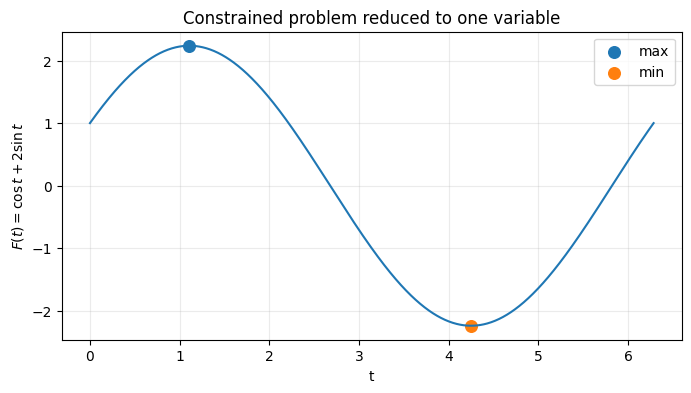

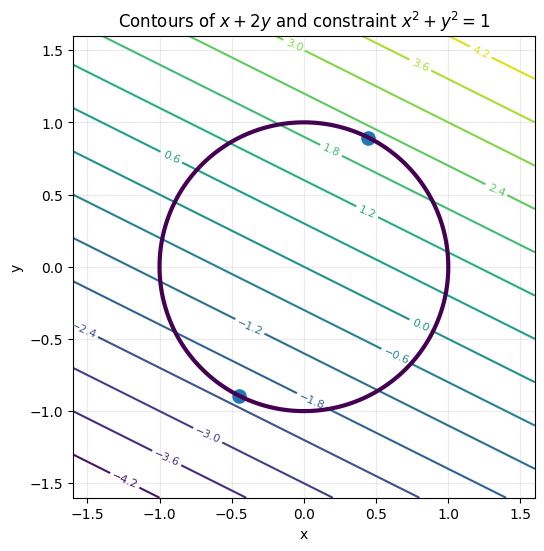

In [3]:
plt.figure(figsize=(8, 4))
plt.plot(t, F_t)
plt.scatter([t[i_max]], [F_t[i_max]], s=70, label="max")
plt.scatter([t[i_min]], [F_t[i_min]], s=70, label="min")
plt.xlabel("t")
plt.ylabel(r"$F(t)=\cos t+2\sin t$")
plt.title("Constrained problem reduced to one variable")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

plot_contours_with_constraint(
    f_linear_xy,
    g_circle_xy,
    c=1,
    xmin=-1.6, xmax=1.6, ymin=-1.6, ymax=1.6,
    levels=15,
    title=r"Contours of $x+2y$ and constraint $x^2+y^2=1$",
    points=np.vstack([analytic_max, analytic_min])
)

## 2. Geometry at the optimum

At the maximum point $p$, the gradient of $f$ and the gradient of the constraint $g$ are parallel:

$$
\nabla f(p)=\lambda\nabla g(p).
$$

Here

$$
\nabla f=\langle 1,2\rangle,
\qquad
\nabla g=\langle 2x,2y\rangle.
$$

p: [0.447214 0.894427]
grad f: [1. 2.]
grad g: [0.894427 1.788854]
lambda from component ratio: 1.118033988749895 1.118033988749895


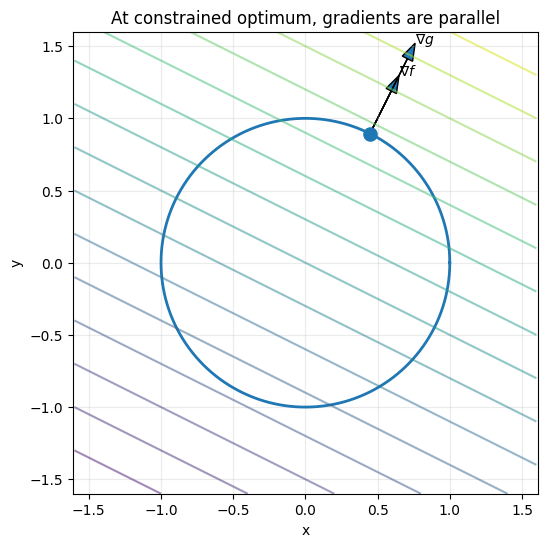

In [4]:
p = analytic_max
grad_f = np.array([1.0, 2.0])
grad_g = np.array([2*p[0], 2*p[1]])

print("p:", p)
print("grad f:", grad_f)
print("grad g:", grad_g)
print("lambda from component ratio:", grad_f[0]/grad_g[0], grad_f[1]/grad_g[1])

theta = np.linspace(0, 2*np.pi, 500)
plt.figure(figsize=(6, 6))
plt.plot(np.cos(theta), np.sin(theta), linewidth=2, label="constraint")
plt.contour(*make_grid(-1.6, 1.6, -1.6, 1.6, n=250)[2:],
            f_linear_xy(make_grid(-1.6, 1.6, -1.6, 1.6, n=250)[2],
                        make_grid(-1.6, 1.6, -1.6, 1.6, n=250)[3]),
            levels=15, alpha=0.5)
draw_vector(plt.gca(), p, unit(grad_f), label=r"$\nabla f$", scale=0.45)
draw_vector(plt.gca(), p, unit(grad_g), label=r"$\nabla g$", scale=0.70)
plt.scatter([p[0]], [p[1]], s=90)
plt.xlabel("x")
plt.ylabel("y")
plt.title("At constrained optimum, gradients are parallel")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

### Guided task 1

For

$$
f(x,y)=3x-y
$$

on the unit circle, find the maximum and minimum points using parameterization and compare with the vector formula.

In [5]:
def f_task1_xy(X, Y):
    return 3*X - Y

F = f_task1_xy(np.cos(t), np.sin(t))
pmax = np.array([np.cos(t[np.argmax(F)]), np.sin(t[np.argmax(F)])])
pmin = np.array([np.cos(t[np.argmin(F)]), np.sin(t[np.argmin(F)])])

print("Parameterization max point:", pmax, "value:", np.max(F))
print("Parameterization min point:", pmin, "value:", np.min(F))
print("Analytic max point:", unit([3, -1]))
print("Analytic min point:", -unit([3, -1]))
print("Analytic max value:", norm([3, -1]))

Parameterization max point: [ 0.948995 -0.315291] value: 3.162276118809079
Parameterization min point: [-0.947999  0.318274] value: -3.162270300979895
Analytic max point: [ 0.948683 -0.316228]
Analytic min point: [-0.948683  0.316228]
Analytic max value: 3.1622776601683795


---

# Part II. Lagrange multiplier equations

For one equality constraint

$$
g(x,y)=c,
$$

the Lagrange equations are

$$
\nabla f(x,y)=\lambda\nabla g(x,y),
\qquad
g(x,y)=c.
$$

This gives three equations for $x,y,\lambda$.

## 3. Solve the circle problem with Lagrange multipliers

For

$$
f(x,y)=x+2y,\qquad g(x,y)=x^2+y^2=1,
$$

the equations are

$$
1=2\lambda x,\qquad 2=2\lambda y,\qquad x^2+y^2=1.
$$

In [6]:
def F_lagrange_linear_circle(z):
    x, y, lam = z
    return np.array([
        1 - 2*lam*x,
        2 - 2*lam*y,
        x**2 + y**2 - 1
    ], dtype=float)

def J_lagrange_linear_circle(z):
    x, y, lam = z
    return np.array([
        [-2*lam, 0, -2*x],
        [0, -2*lam, -2*y],
        [2*x, 2*y, 0]
    ], dtype=float)

starts = [
    np.array([0.8, 0.6, 1.0]),
    np.array([-0.8, -0.6, -1.0])
]

solutions = []
for s in starts:
    sol, hist = newton_system(F_lagrange_linear_circle, J_lagrange_linear_circle, s)
    solutions.append(sol)
    print("start:", s)
    print("solution [x,y,lambda]:", sol)
    print("constraint:", sol[0]**2 + sol[1]**2)
    print("f value:", f_linear_xy(sol[0], sol[1]))
    print()

start: [0.8 0.6 1. ]
solution [x,y,lambda]: [0.447214 0.894427 1.118034]
constraint: 0.9999999999999999
f value: 2.23606797749979

start: [-0.8 -0.6 -1. ]
solution [x,y,lambda]: [-0.447214 -0.894427 -1.118034]
constraint: 0.9999999999999999
f value: -2.23606797749979



## 4. A quadratic objective on the unit circle

Let

$$
f(x,y)=4x^2+y^2
$$

subject to

$$
x^2+y^2=1.
$$

Because the constraint is the unit circle, this problem asks for the largest and smallest value of a quadratic form on unit vectors.

Maximum point from parameterization: (np.float64(1.0), np.float64(0.0)) value: 4.0
Minimum point from parameterization: (np.float64(-0.001572368047584414), np.float64(0.9999987638285974)) value: 1.0000074170238311


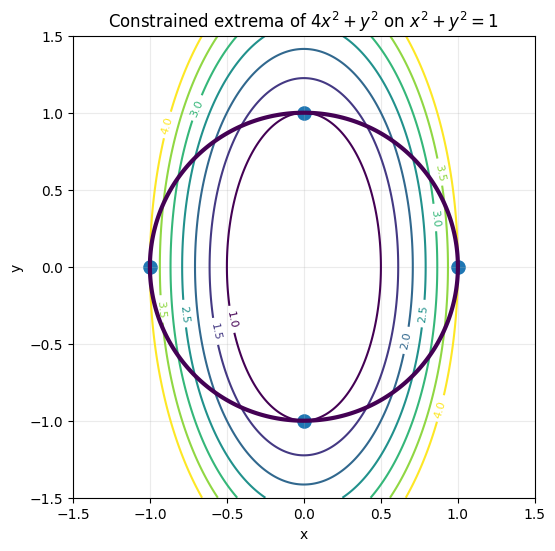

In [7]:
def f_quad_circle_xy(X, Y):
    return 4*X**2 + Y**2

def grad_f_quad_circle(p):
    x, y = p
    return np.array([8*x, 2*y], dtype=float)

F = f_quad_circle_xy(np.cos(t), np.sin(t))
idx_max = np.argmax(F)
idx_min = np.argmin(F)

print("Maximum point from parameterization:", (np.cos(t[idx_max]), np.sin(t[idx_max])), "value:", F[idx_max])
print("Minimum point from parameterization:", (np.cos(t[idx_min]), np.sin(t[idx_min])), "value:", F[idx_min])

plot_contours_with_constraint(
    f_quad_circle_xy,
    g_circle_xy,
    c=1,
    xmin=-1.5, xmax=1.5, ymin=-1.5, ymax=1.5,
    levels=[1, 1.5, 2, 2.5, 3, 3.5, 4],
    title=r"Constrained extrema of $4x^2+y^2$ on $x^2+y^2=1$",
    points=np.array([[1,0],[-1,0],[0,1],[0,-1]])
)

## 5. Lagrange equations for the quadratic objective

The equations are

$$
8x=2\lambda x,\qquad 2y=2\lambda y,\qquad x^2+y^2=1.
$$

The solutions occur at the coordinate axes:

$$
(\pm1,0),\qquad (0,\pm1).
$$

In [8]:
candidate_points = np.array([
    [1, 0],
    [-1, 0],
    [0, 1],
    [0, -1]
], dtype=float)

for p in candidate_points:
    print("point:", p, "f:", f_quad_circle_xy(p[0], p[1]), "grad f:", grad_f_quad_circle(p), "grad g:", 2*p)

point: [1. 0.] f: 4.0 grad f: [8. 0.] grad g: [2. 0.]
point: [-1.  0.] f: 4.0 grad f: [-8.  0.] grad g: [-2.  0.]
point: [0. 1.] f: 1.0 grad f: [0. 2.] grad g: [0. 2.]
point: [ 0. -1.] f: 1.0 grad f: [ 0. -2.] grad g: [ 0. -2.]


---

# Part III. Ellipse constraints

An ellipse can be parameterized as

$$
x=a\cos t,\qquad y=b\sin t.
$$

It can also be handled using Lagrange multipliers.

## 6. Maximize $xy$ on an ellipse

Let

$$
f(x,y)=xy
$$

subject to

$$
\frac{x^2}{4}+y^2=1.
$$

The ellipse has semi-axis lengths $2$ and $1$.

Max point:

 (np.float64(1.4136578150471493), np.float64(0.7073845456956421)) value: 0.9999996912662218
Min point: (np.float64(1.4136578150471486), np.float64(-0.7073845456956425)) value: -0.9999996912662218


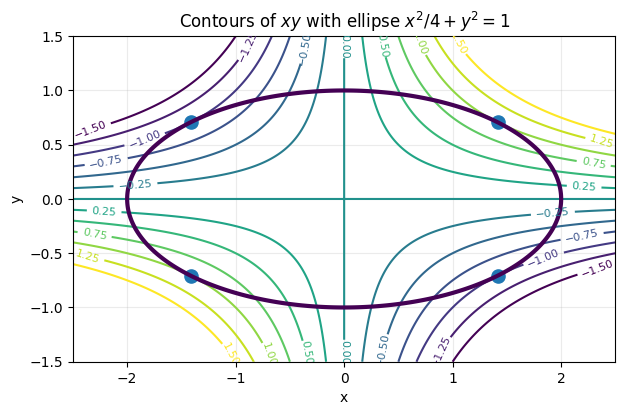

In [9]:
def f_xy_product(X, Y):
    return X*Y

def g_ellipse_xy(X, Y):
    return X**2/4 + Y**2

t = np.linspace(0, 2*np.pi, 2000)
x_ell = 2*np.cos(t)
y_ell = np.sin(t)
F = f_xy_product(x_ell, y_ell)

idx_max = np.argmax(F)
idx_min = np.argmin(F)

print("Max point:", (x_ell[idx_max], y_ell[idx_max]), "value:", F[idx_max])
print("Min point:", (x_ell[idx_min], y_ell[idx_min]), "value:", F[idx_min])

plot_contours_with_constraint(
    f_xy_product,
    g_ellipse_xy,
    c=1,
    xmin=-2.5, xmax=2.5, ymin=-1.5, ymax=1.5,
    levels=np.linspace(-1.5, 1.5, 13),
    title=r"Contours of $xy$ with ellipse $x^2/4+y^2=1$",
    points=np.array([[np.sqrt(2), 1/np.sqrt(2)], [-np.sqrt(2), -1/np.sqrt(2)],
                     [np.sqrt(2), -1/np.sqrt(2)], [-np.sqrt(2), 1/np.sqrt(2)]])
)

## 7. Lagrange equations for the ellipse problem

For

$$
f(x,y)=xy,
\qquad
g(x,y)=\frac{x^2}{4}+y^2,
$$

the equations are

$$
y=\lambda \frac{x}{2},\qquad
x=\lambda 2y,\qquad
\frac{x^2}{4}+y^2=1.
$$

In [10]:
ellipse_candidates = np.array([
    [np.sqrt(2), 1/np.sqrt(2)],
    [-np.sqrt(2), -1/np.sqrt(2)],
    [np.sqrt(2), -1/np.sqrt(2)],
    [-np.sqrt(2), 1/np.sqrt(2)]
])

for p in ellipse_candidates:
    x, y = p
    grad_f = np.array([y, x])
    grad_g = np.array([x/2, 2*y])
    print("point:", p)
    print("  f value:", f_xy_product(x, y))
    print("  grad f:", grad_f)
    print("  grad g:", grad_g)
    print("  lambda least-squares estimate:", np.dot(grad_f, grad_g)/np.dot(grad_g, grad_g))
    print()

point: [1.414214 0.707107]
  f value: 1.0
  grad f: [0.707107 1.414214]
  grad g: [0.707107 1.414214]
  lambda least-squares estimate: 1.0000000000000002

point: [-1.414214 -0.707107]
  f value: 1.0
  grad f: [-0.707107 -1.414214]
  grad g: [-0.707107 -1.414214]
  lambda least-squares estimate: 1.0000000000000002

point: [ 1.414214 -0.707107]
  f value: -1.0
  grad f: [-0.707107  1.414214]
  grad g: [ 0.707107 -1.414214]
  lambda least-squares estimate: -1.0000000000000002

point: [-1.414214  0.707107]
  f value: -1.0
  grad f: [ 0.707107 -1.414214]
  grad g: [-0.707107  1.414214]
  lambda least-squares estimate: -1.0000000000000002



---

# Part IV. Constrained optimization in three dimensions

For a constraint surface

$$
g(x,y,z)=c,
$$

a constrained extremum of $f(x,y,z)$ satisfies

$$
\nabla f=\lambda\nabla g.
$$

## 8. Maximize a linear function on a sphere

Maximize

$$
f(x,y,z)=x+2y+3z
$$

subject to

$$
x^2+y^2+z^2=1.
$$

The answer is obtained by aligning $\langle x,y,z\rangle$ with $\langle 1,2,3\rangle$.

In [11]:
a_vec = np.array([1.0, 2.0, 3.0])
p_max = unit(a_vec)
p_min = -p_max

print("Maximum point:", p_max)
print("Maximum value:", np.dot(a_vec, p_max))
print("Minimum point:", p_min)
print("Minimum value:", np.dot(a_vec, p_min))
print("Expected max/min values:", norm(a_vec), -norm(a_vec))

Maximum point: [0.267261 0.534522 0.801784]
Maximum value: 3.7416573867739413
Minimum point: [-0.267261 -0.534522 -0.801784]
Minimum value: -3.7416573867739413
Expected max/min values: 3.7416573867739413 -3.7416573867739413


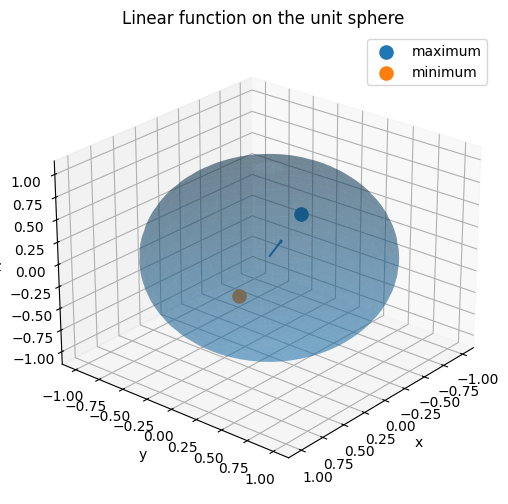

In [12]:
def sphere_points(radius=1, n_u=120, n_v=60):
    u = np.linspace(0, 2*np.pi, n_u)
    v = np.linspace(0, np.pi, n_v)
    U, V = np.meshgrid(u, v)
    X = radius*np.cos(U)*np.sin(V)
    Y = radius*np.sin(U)*np.sin(V)
    Z = radius*np.cos(V)
    return X, Y, Z

X, Y, Z = sphere_points()

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, alpha=0.35, linewidth=0)
ax.scatter([p_max[0]], [p_max[1]], [p_max[2]], s=90, label="maximum")
ax.scatter([p_min[0]], [p_min[1]], [p_min[2]], s=90, label="minimum")
ax.quiver(0, 0, 0, a_vec[0], a_vec[1], a_vec[2],
          length=0.4, normalize=True, arrow_length_ratio=0.12)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(r"Linear function on the unit sphere")
ax.legend()
ax.view_init(elev=25, azim=40)
plt.show()

## 9. Closest point on a plane

Find the point on the plane

$$
x+2y+2z=5
$$

closest to

$$
P=(1,1,1).
$$

This can be written as minimizing

$$
f(x,y,z)=(x-1)^2+(y-1)^2+(z-1)^2
$$

subject to the plane constraint.

In [13]:
P = np.array([1.0, 1.0, 1.0])
normal = np.array([1.0, 2.0, 2.0])
c = 5.0

# Projection formula: Q = P + alpha n, with n dot Q = c.
alpha = (c - np.dot(normal, P)) / np.dot(normal, normal)
Q = P + alpha*normal

print("Closest point Q:", Q)
print("Plane check n dot Q:", np.dot(normal, Q))
print("Distance from P to plane:", norm(Q - P))

# Lagrange multiplier interpretation:
# grad f = 2(Q-P) = lambda normal.
lambda_est = 2*np.dot(Q - P, normal) / np.dot(normal, normal)
print("lambda:", lambda_est)
print("grad f at Q:", 2*(Q - P))
print("lambda grad constraint:", lambda_est*normal)

Closest point Q: [1. 1. 1.]
Plane check n dot Q: 5.0
Distance from P to plane: 0.0
lambda: 0.0
grad f at Q: [0. 0. 0.]
lambda grad constraint: [0. 0. 0.]


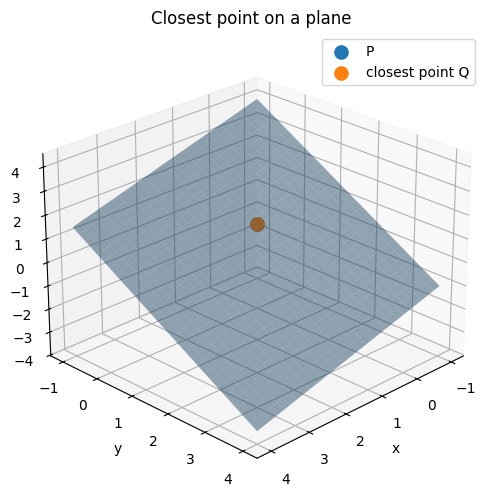

In [14]:
xx = np.linspace(-1, 4, 30)
yy = np.linspace(-1, 4, 30)
XX, YY = np.meshgrid(xx, yy)
ZZ = (c - XX - 2*YY)/2

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(XX, YY, ZZ, alpha=0.45, linewidth=0)
ax.scatter([P[0]], [P[1]], [P[2]], s=90, label="P")
ax.scatter([Q[0]], [Q[1]], [Q[2]], s=90, label="closest point Q")
ax.plot([P[0], Q[0]], [P[1], Q[1]], [P[2], Q[2]], linewidth=3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Closest point on a plane")
ax.legend()
ax.view_init(elev=25, azim=45)
plt.show()

---

# Part V. Multiple constraints

With two constraints

$$
g_1(x,y,z)=c_1,\qquad g_2(x,y,z)=c_2,
$$

the Lagrange condition becomes

$$
\nabla f=\lambda\nabla g_1+\mu\nabla g_2.
$$

The feasible set is usually a curve in space.

## 10. Closest point to a line as a two-constraint problem

Find the point closest to $P=(2,0,1)$ on the line

$$
x+y=1,\qquad z=2.
$$

Minimize

$$
f(x,y,z)=(x-2)^2+y^2+(z-1)^2
$$

subject to the two constraints.

In [15]:
P = np.array([2.0, 0.0, 1.0])

# Constraints:
# g1 = x+y = 1
# g2 = z = 2
# Parameterize line: y = 1-x, z=2.
x_line = np.linspace(-1, 3, 500)
y_line = 1 - x_line
z_line = np.full_like(x_line, 2.0)

dist2 = (x_line - P[0])**2 + (y_line - P[1])**2 + (z_line - P[2])**2
idx = np.argmin(dist2)
Q = np.array([x_line[idx], y_line[idx], z_line[idx]])

# Exact solution: minimize (x-2)^2 + (1-x)^2 + 1.
x_exact = 1.5
Q_exact = np.array([x_exact, 1-x_exact, 2.0])

print("Numerical closest point:", Q)
print("Exact closest point:", Q_exact)
print("Minimum distance:", norm(Q_exact - P))
print("Constraint checks:", Q_exact[0] + Q_exact[1], Q_exact[2])

Numerical closest point: [ 1.501002 -0.501002  2.      ]
Exact closest point: [ 1.5 -0.5  2. ]
Minimum distance: 1.224744871391589
Constraint checks: 1.0 2.0


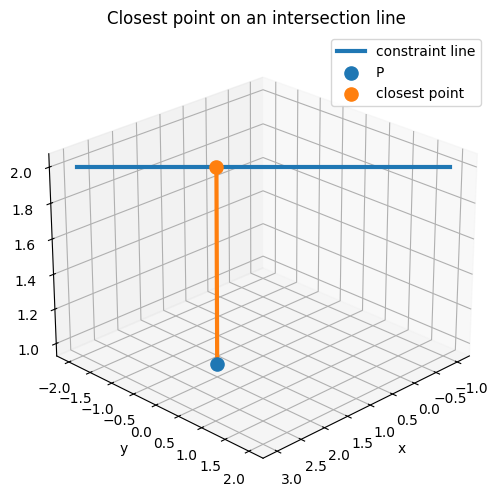

In [16]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(x_line, y_line, z_line, linewidth=3, label="constraint line")
ax.scatter([P[0]], [P[1]], [P[2]], s=90, label="P")
ax.scatter([Q_exact[0]], [Q_exact[1]], [Q_exact[2]], s=90, label="closest point")
ax.plot([P[0], Q_exact[0]], [P[1], Q_exact[1]], [P[2], Q_exact[2]], linewidth=3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Closest point on an intersection line")
ax.legend()
ax.view_init(elev=25, azim=45)
plt.show()

## 11. Check the multiple-constraint Lagrange condition

For

$$
g_1=x+y,\qquad g_2=z,
$$

we have

$$
\nabla g_1=\langle1,1,0\rangle,\qquad
\nabla g_2=\langle0,0,1\rangle.
$$

At the closest point $Q$, the vector $\nabla f(Q)=2(Q-P)$ should be a linear combination of these two constraint normals.

In [17]:
grad_f_Q = 2*(Q_exact - P)
grad_g1 = np.array([1.0, 1.0, 0.0])
grad_g2 = np.array([0.0, 0.0, 1.0])
A = np.column_stack([grad_g1, grad_g2])
lambdas, *_ = np.linalg.lstsq(A, grad_f_Q, rcond=None)

print("grad f at Q:", grad_f_Q)
print("lambda, mu:", lambdas)
print("lambda grad g1 + mu grad g2:", A @ lambdas)

grad f at Q: [-1. -1.  2.]
lambda, mu: [-1.  2.]
lambda grad g1 + mu grad g2: [-1. -1.  2.]


---

# Part VI. Boundary and inequality constraints

If the feasible set is a closed region, extrema may occur:

1. at interior critical points;
2. on boundary curves;
3. at corners or nonsmooth boundary points.

Lagrange multipliers are usually used on smooth boundary pieces, but all boundary components must be checked.

## 12. Optimize on a rectangle

Let

$$
f(x,y)=x^2-2x+y^2+4y
$$

on the rectangle

$$
-1\le x\le 3,\qquad -4\le y\le 1.
$$

We check the interior critical point and the four boundary edges.

In [18]:
def f_rect_xy(X, Y):
    return X**2 - 2*X + Y**2 + 4*Y

def f_rect_p(p):
    x, y = p
    return x**2 - 2*x + y**2 + 4*y

# Unconstrained critical point from gradient: 2x-2=0, 2y+4=0.
p_crit = np.array([1.0, -2.0])
print("Interior critical point:", p_crit, "value:", f_rect_p(p_crit))

# Boundary sampling
N = 1000
edges = []
x_vals = np.linspace(-1, 3, N)
y_vals = np.linspace(-4, 1, N)

edges.append(np.column_stack([x_vals, np.full(N, -4)]))
edges.append(np.column_stack([x_vals, np.full(N, 1)]))
edges.append(np.column_stack([np.full(N, -1), y_vals]))
edges.append(np.column_stack([np.full(N, 3), y_vals]))

points = [p_crit]
for edge in edges:
    vals = np.array([f_rect_p(p) for p in edge])
    points.append(edge[np.argmin(vals)])
    points.append(edge[np.argmax(vals)])

corners = np.array([[-1,-4],[-1,1],[3,-4],[3,1]], dtype=float)
points.extend(corners)

# Deduplicate approximately
candidates = []
for p in points:
    if not any(norm(p-q) < 1e-4 for q in candidates):
        candidates.append(p)
candidates = np.array(candidates)

vals = np.array([f_rect_p(p) for p in candidates])
i_min = np.argmin(vals)
i_max = np.argmax(vals)

print("Candidate points and values:")
for p, val in zip(candidates, vals):
    print(p, val)

print("\nGlobal minimum:", candidates[i_min], vals[i_min])
print("Global maximum:", candidates[i_max], vals[i_max])

Interior critical point: [ 1. -2.] value: -5.0
Candidate points and values:
[ 1. -2.] -5.0
[ 0.997998 -4.      ] -0.9999959919879835
[-1. -4.] 3.0
[0.997998 1.      ] 4.0000040080120165
[-1.  1.] 8.0
[-1.       -1.997998] -0.9999959919879835
[ 3.       -1.997998] -0.9999959919879835
[3. 1.] 8.0
[ 3. -4.] 3.0

Global minimum: [ 1. -2.] -5.0
Global maximum: [-1.  1.] 8.0


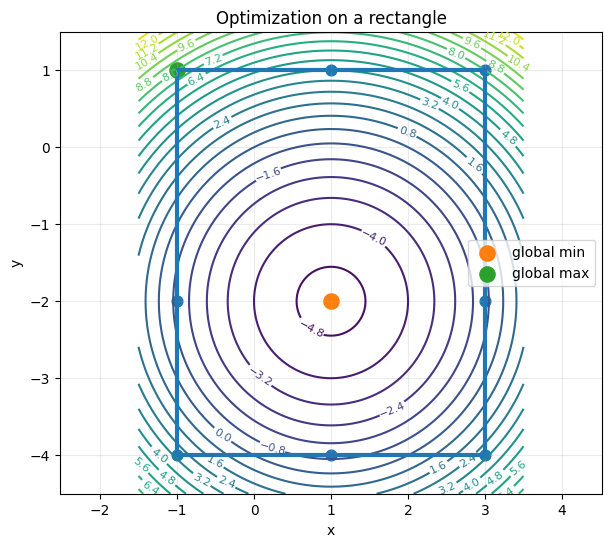

In [19]:
x, y, X, Y = make_grid(-1.5, 3.5, -4.5, 1.5, n=300)
Z = f_rect_xy(X, Y)

plt.figure(figsize=(7, 6))
cs = plt.contour(X, Y, Z, levels=25)
plt.clabel(cs, inline=True, fontsize=8)
rect = np.array([[-1,-4],[3,-4],[3,1],[-1,1],[-1,-4]])
plt.plot(rect[:,0], rect[:,1], linewidth=3)
plt.scatter(candidates[:,0], candidates[:,1], s=60)
plt.scatter([candidates[i_min,0]], [candidates[i_min,1]], s=120, label="global min")
plt.scatter([candidates[i_max,0]], [candidates[i_max,1]], s=120, label="global max")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Optimization on a rectangle")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

### Key lesson

For inequality constraints and closed regions, do not stop after solving interior equations.  
Check every boundary piece and every corner.

---

# Part VII. Projected gradient methods

A projected gradient method alternates between:

1. taking a gradient step;
2. projecting back to the feasible set.

For the unit circle, projection is simple:

$$
\operatorname{proj}(p)=\frac{p}{\|p\|}.
$$

## 13. Projected gradient ascent on the unit circle

Maximize

$$
f(x,y)=x+2y
$$

subject to

$$
x^2+y^2=1.
$$

In [20]:
def project_to_unit_circle(p):
    return unit(p)

def grad_linear_circle(p):
    return np.array([1.0, 2.0])

p = unit(np.array([-0.8, 0.4]))
eta = 0.15
path = [p.copy()]
values = [np.dot(np.array([1.0, 2.0]), p)]

for k in range(50):
    p = p + eta*grad_linear_circle(p)
    p = project_to_unit_circle(p)
    path.append(p.copy())
    values.append(np.dot(np.array([1.0, 2.0]), p))

path = np.array(path)
values = np.array(values)

print("Start:", path[0], "value:", values[0])
print("End:", path[-1], "value:", values[-1])
print("Analytic maximizer:", analytic_max, "value:", norm([1,2]))

Start: [-0.894427  0.447214] value: 0.0
End: [0.447213 0.894428] value: 2.2360679774987853
Analytic maximizer: [0.447214 0.894427] value: 2.23606797749979


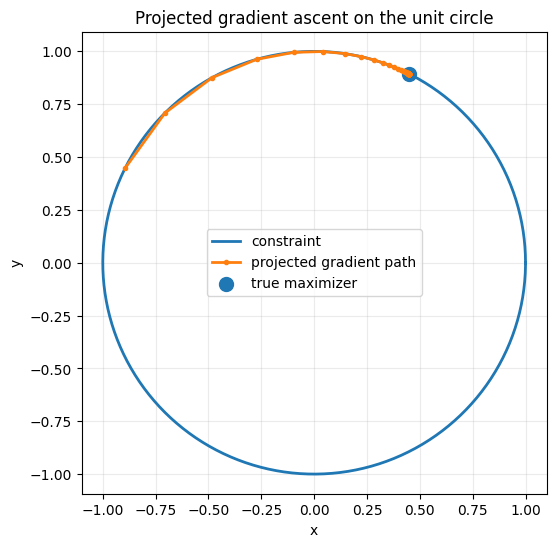

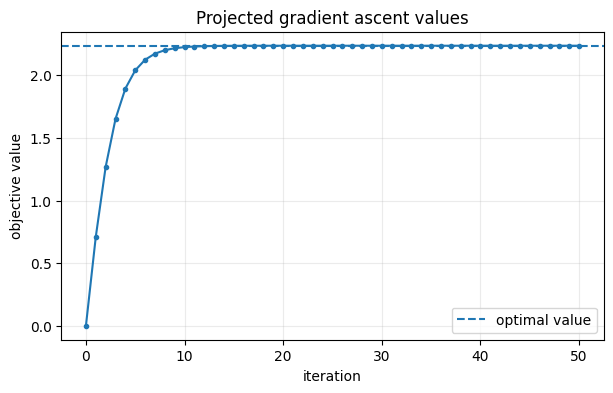

In [21]:
theta = np.linspace(0, 2*np.pi, 500)
plt.figure(figsize=(6, 6))
plt.plot(np.cos(theta), np.sin(theta), linewidth=2, label="constraint")
plt.plot(path[:,0], path[:,1], marker="o", markersize=3, linewidth=2, label="projected gradient path")
plt.scatter([analytic_max[0]], [analytic_max[1]], s=100, label="true maximizer")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Projected gradient ascent on the unit circle")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(values, marker="o", markersize=3)
plt.axhline(norm([1,2]), linestyle="--", label="optimal value")
plt.xlabel("iteration")
plt.ylabel("objective value")
plt.title("Projected gradient ascent values")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 14. Tangential gradient on a constraint

An alternative is to remove the component of the gradient normal to the constraint.

On the unit circle, the normal direction at $p$ is $p$.  
The tangential component of a vector $v$ is

$$
v_{\text{tan}}=v-(v\cdot p)p.
$$

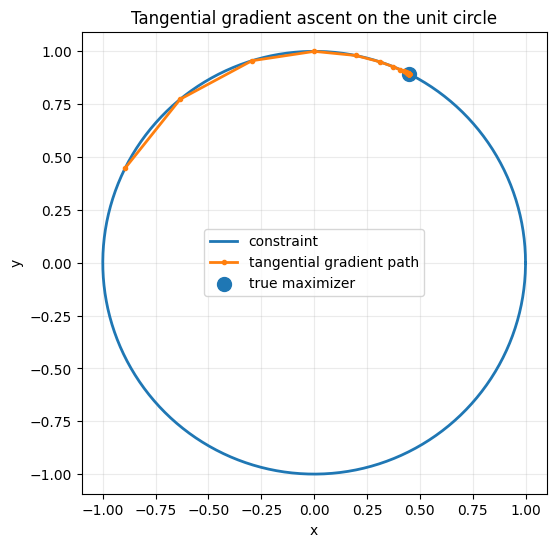

In [22]:
p = unit(np.array([-0.8, 0.4]))
eta = 0.20
path_tan = [p.copy()]
values_tan = [np.dot(np.array([1.0, 2.0]), p)]

for k in range(60):
    grad = np.array([1.0, 2.0])
    grad_tan = grad - np.dot(grad, p)*p
    p = p + eta*grad_tan
    p = unit(p)
    path_tan.append(p.copy())
    values_tan.append(np.dot(np.array([1.0, 2.0]), p))

path_tan = np.array(path_tan)

plt.figure(figsize=(6, 6))
plt.plot(np.cos(theta), np.sin(theta), linewidth=2, label="constraint")
plt.plot(path_tan[:,0], path_tan[:,1], marker="o", markersize=3, linewidth=2, label="tangential gradient path")
plt.scatter([analytic_max[0]], [analytic_max[1]], s=100, label="true maximizer")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Tangential gradient ascent on the unit circle")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

---

# Part VIII. Penalty methods

A penalty method replaces a constrained problem with an unconstrained one by adding a penalty term.

For the constraint

$$
g(x,y)=0,
$$

we minimize or maximize an objective with a large penalty:

$$
\Phi_\rho(x,y)=f(x,y)+\rho g(x,y)^2
$$

for minimization, or

$$
\Psi_\rho(x,y)=f(x,y)-\rho g(x,y)^2
$$

for maximization.

As $\rho$ increases, violation of the constraint becomes more expensive.

## 15. Penalized maximization on a circle

Maximize

$$
f(x,y)=x+2y
$$

subject to

$$
x^2+y^2=1.
$$

We maximize

$$
\Psi_\rho(x,y)=x+2y-\rho(x^2+y^2-1)^2.
$$

In [23]:
def penalty_objective_xy(X, Y, rho=10):
    return X + 2*Y - rho*(X**2 + Y**2 - 1)**2

def penalty_objective_p(p, rho=10):
    x, y = p
    return x + 2*y - rho*(x**2 + y**2 - 1)**2

def grad_penalty_p(p, rho=10):
    x, y = p
    g = x**2 + y**2 - 1
    return np.array([
        1 - rho*4*x*g,
        2 - rho*4*y*g
    ], dtype=float)

def gradient_ascent(obj, grad, start, eta=0.03, steps=200):
    p = np.asarray(start, dtype=float)
    path = [p.copy()]
    values = [obj(p)]
    for k in range(steps):
        p = p + eta*grad(p)
        path.append(p.copy())
        values.append(obj(p))
    return np.array(path), np.array(values)

for rho in [1, 5, 20, 100]:
    obj = lambda p, rho=rho: penalty_objective_p(p, rho=rho)
    grad = lambda p, rho=rho: grad_penalty_p(p, rho=rho)
    path_pen, vals_pen = gradient_ascent(obj, grad, start=np.array([0.0, 0.0]), eta=0.015, steps=300)
    p_final = path_pen[-1]
    print("rho =", rho)
    print("  final point:", p_final)
    print("  objective f:", np.dot(np.array([1.0,2.0]), p_final))
    print("  constraint x^2+y^2:", np.dot(p_final, p_final))
    print("  distance to true maximizer:", norm(p_final - analytic_max))

rho = 1
  final point: [0.540793 1.081586]
  objective f: 2.703963998819841
  constraint x^2+y^2: 1.4622842613827571
  distance to true maximizer: 0.20924946201466518
rho = 5
  final point: [0.470382 0.940764]
  objective f: 2.351910461335324
  constraint x^2+y^2: 1.106296563627707
  distance to true maximizer: 0.05180633370773493
rho = 20
  final point: [0.340082 0.680165]
  objective f: 1.7004124561794822
  constraint x^2+y^2: 0.5782805042260679
  distance to true maximizer: 0.239552431639059
rho = 100
  final point: [nan nan]
  objective f: nan
  constraint x^2+y^2: nan
  distance to true maximizer: nan


/tmp/ipykernel_14679/3285758797.py:6: RuntimeWarning: overflow encountered in scalar power
  return x + 2*y - rho*(x**2 + y**2 - 1)**2
/tmp/ipykernel_14679/3285758797.py:12: RuntimeWarning: overflow encountered in scalar multiply
  1 - rho*4*x*g,
/tmp/ipykernel_14679/3285758797.py:13: RuntimeWarning: overflow encountered in scalar multiply
  2 - rho*4*y*g
/tmp/ipykernel_14679/3285758797.py:6: RuntimeWarning: invalid value encountered in scalar subtract
  return x + 2*y - rho*(x**2 + y**2 - 1)**2
/tmp/ipykernel_14679/3285758797.py:21: RuntimeWarning: invalid value encountered in add
  p = p + eta*grad(p)


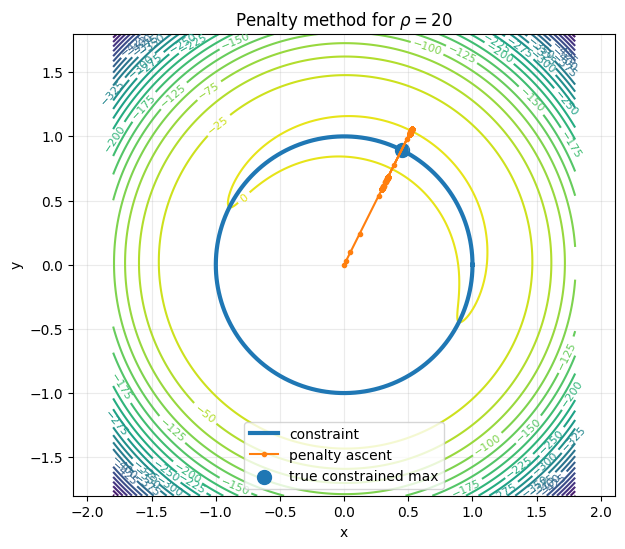

In [24]:
rho = 20
x, y, X, Y = make_grid(-1.8, 1.8, -1.8, 1.8, n=300)
Z = penalty_objective_xy(X, Y, rho=rho)

plt.figure(figsize=(7, 6))
cs = plt.contour(X, Y, Z, levels=25)
plt.clabel(cs, inline=True, fontsize=8)
plt.plot(np.cos(theta), np.sin(theta), linewidth=3, label="constraint")
obj = lambda p: penalty_objective_p(p, rho=rho)
grad = lambda p: grad_penalty_p(p, rho=rho)
path_pen, vals_pen = gradient_ascent(obj, grad, start=np.array([0.0, 0.0]), eta=0.015, steps=300)
plt.plot(path_pen[:,0], path_pen[:,1], marker="o", markersize=3, label="penalty ascent")
plt.scatter([analytic_max[0]], [analytic_max[1]], s=100, label="true constrained max")
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Penalty method for $\rho=20$")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

### Interpretation

Penalty methods are useful, but they are approximate.  
Large penalties enforce the constraint more strongly but can make the optimization problem numerically stiff.

---

# Part IX. Constrained least squares example

In data science, constraints are often used to impose structure:

- weights must sum to one;
- probabilities must be nonnegative and sum to one;
- portfolio weights must satisfy budget constraints;
- model parameters may be regularized or bounded.

Here we solve a simple constrained least-squares problem:

$$
\min_w \|Aw-b\|^2
\quad\text{subject to}\quad
\sum_i w_i=1.
$$

## 16. Equality-constrained least squares

The Lagrange equations for

$$
\min_w \|Aw-b\|^2
\quad\text{subject to}\quad
\mathbf 1^T w=1
$$

are

$$
2A^T(Aw-b)+\lambda\mathbf 1=0,
\qquad
\mathbf 1^T w=1.
$$

This is a linear system in $w$ and $\lambda$.

In [25]:
rng = np.random.default_rng(12)

m, n = 8, 3
A = rng.normal(size=(m, n))
true_w = np.array([0.2, 0.5, 0.3])
b = A @ true_w + 0.05*rng.normal(size=m)

# Build KKT system:
# [2A^T A   1][w]   [2A^T b]
# [1^T      0][λ] = [1]
KKT = np.block([
    [2*A.T@A, np.ones((n,1))],
    [np.ones((1,n)), np.zeros((1,1))]
])
rhs = np.concatenate([2*A.T@b, [1.0]])

sol = np.linalg.solve(KKT, rhs)
w_constrained = sol[:n]
lam = sol[-1]

# Unconstrained solution
w_unconstrained, *_ = np.linalg.lstsq(A, b, rcond=None)

print("Constrained weights:", w_constrained)
print("Sum constrained weights:", np.sum(w_constrained))
print("Lagrange multiplier:", lam)
print("Unconstrained weights:", w_unconstrained)
print("Sum unconstrained weights:", np.sum(w_unconstrained))
print("Constrained loss:", norm(A@w_constrained - b)**2)
print("Unconstrained loss:", norm(A@w_unconstrained - b)**2)

Constrained weights: [0.16666  0.513709 0.31963 ]
Sum constrained weights: 0.9999999999999999
Lagrange multiplier: -0.13631444500190787
Unconstrained weights: [0.168923 0.503003 0.302963]
Sum unconstrained weights: 0.974888248458079
Constrained loss: 0.00811482751791795
Unconstrained loss: 0.006403280280686545


## 17. Visualize weights

The constrained solution lies on the plane $w_1+w_2+w_3=1$.

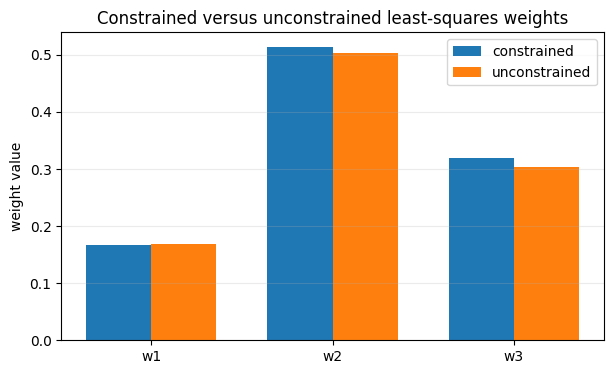

In [26]:
labels = ["w1", "w2", "w3"]
xpos = np.arange(n)

plt.figure(figsize=(7, 4))
plt.bar(xpos - 0.18, w_constrained, width=0.36, label="constrained")
plt.bar(xpos + 0.18, w_unconstrained, width=0.36, label="unconstrained")
plt.xticks(xpos, labels)
plt.ylabel("weight value")
plt.title("Constrained versus unconstrained least-squares weights")
plt.legend()
plt.grid(True, axis="y", alpha=0.25)
plt.show()

---

# Part X. Chapter mini-project: design a constrained optimizer

In this mini-project, you compare three approaches for maximizing

$$
f(x,y)=2x+y
$$

subject to the ellipse

$$
\frac{x^2}{4}+y^2=1.
$$

Methods:

1. parameterization;
2. Lagrange multipliers;
3. projected/tangential gradient search.

## 18. Parameterization method

In [27]:
def f_project_xy(X, Y):
    return 2*X + Y

t = np.linspace(0, 2*np.pi, 3000)
x_ell = 2*np.cos(t)
y_ell = np.sin(t)
F = f_project_xy(x_ell, y_ell)

p_param_max = np.array([x_ell[np.argmax(F)], y_ell[np.argmax(F)]])
p_param_min = np.array([x_ell[np.argmin(F)], y_ell[np.argmin(F)]])

print("Parameterization maximum:", p_param_max, "value:", np.max(F))
print("Parameterization minimum:", p_param_min, "value:", np.min(F))

Parameterization maximum: [1.940214 0.242678] value: 4.1231055809042525
Parameterization minimum: [-1.940721 -0.241662] value: -4.123103954742209


## 19. Lagrange multiplier method

For

$$
f(x,y)=2x+y,
\qquad
g(x,y)=\frac{x^2}{4}+y^2,
$$

the equations are

$$
2=\lambda \frac{x}{2},\qquad 1=2\lambda y,\qquad \frac{x^2}{4}+y^2=1.
$$

In [28]:
# Solve analytically from gradients:
# x = 4/lambda, y = 1/(2lambda)
# constraint gives 4/lambda^2 + 1/(4lambda^2) = 1
# lambda^2 = 17/4.
lam_abs = np.sqrt(17/4)
p_lag_max = np.array([4/lam_abs, 1/(2*lam_abs)])
p_lag_min = -p_lag_max

print("Lagrange maximum:", p_lag_max, "value:", f_project_xy(p_lag_max[0], p_lag_max[1]))
print("Lagrange minimum:", p_lag_min, "value:", f_project_xy(p_lag_min[0], p_lag_min[1]))
print("Constraint check max:", g_ellipse_xy(p_lag_max[0], p_lag_max[1]))

Lagrange maximum: [1.940285 0.242536] value: 4.123105625617661
Lagrange minimum: [-1.940285 -0.242536] value: -4.123105625617661
Constraint check max: 1.0


## 20. Tangential gradient method on the ellipse

The constraint gradient is

$$
\nabla g=\left\langle \frac{x}{2},2y\right\rangle.
$$

At each point, remove the component of $\nabla f$ in the normal direction $\nabla g$, then take a small step and project back to the ellipse using the parameterization.

In [29]:
def ellipse_project(p):
    """
    Approximate projection to x^2/4 + y^2 = 1 by using the angle of scaled coordinates.
    If q=(x/2,y), project q to unit circle and map back.
    """
    x, y = p
    q = np.array([x/2, y], dtype=float)
    q = unit(q)
    return np.array([2*q[0], q[1]])

def grad_project_f(p):
    return np.array([2.0, 1.0])

def grad_project_g(p):
    x, y = p
    return np.array([x/2, 2*y], dtype=float)

p = np.array([-1.5, 0.3])
p = ellipse_project(p)
eta = 0.12
path = [p.copy()]
values = [f_project_xy(p[0], p[1])]

for k in range(80):
    gf = grad_project_f(p)
    gg = grad_project_g(p)
    gf_tan = gf - np.dot(gf, gg)/np.dot(gg, gg)*gg
    p = p + eta*gf_tan
    p = ellipse_project(p)
    path.append(p.copy())
    values.append(f_project_xy(p[0], p[1]))

path = np.array(path)

print("Tangential-gradient final point:", path[-1])
print("Final value:", values[-1])
print("Lagrange maximum:", p_lag_max)

Tangential-gradient final point: [1.940285 0.242536]
Final value: 4.123105625617661
Lagrange maximum: [1.940285 0.242536]


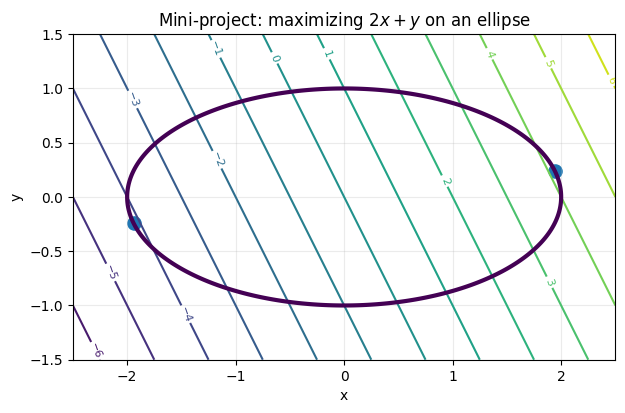

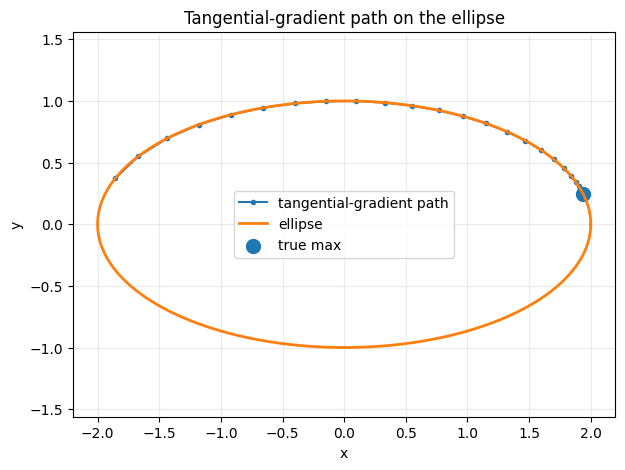

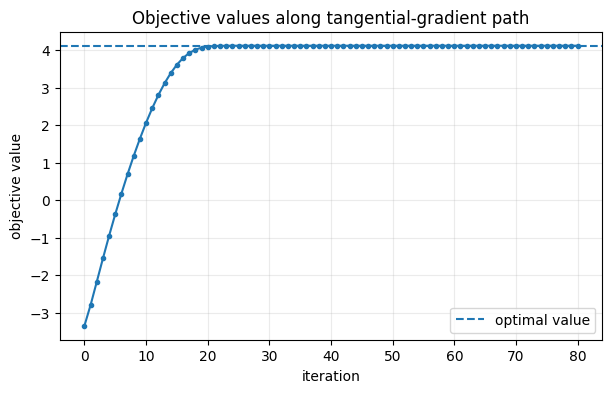

In [30]:
plot_contours_with_constraint(
    f_project_xy,
    g_ellipse_xy,
    c=1,
    xmin=-2.5, xmax=2.5, ymin=-1.5, ymax=1.5,
    levels=14,
    title=r"Mini-project: maximizing $2x+y$ on an ellipse",
    points=np.vstack([p_lag_max, p_lag_min])
)

plt.figure(figsize=(7, 5))
plt.plot(path[:,0], path[:,1], marker="o", markersize=3, label="tangential-gradient path")
plt.plot(2*np.cos(t), np.sin(t), linewidth=2, label="ellipse")
plt.scatter([p_lag_max[0]], [p_lag_max[1]], s=100, label="true max")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Tangential-gradient path on the ellipse")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(values, marker="o", markersize=3)
plt.axhline(f_project_xy(p_lag_max[0], p_lag_max[1]), linestyle="--", label="optimal value")
plt.xlabel("iteration")
plt.ylabel("objective value")
plt.title("Objective values along tangential-gradient path")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 21. Mini-project questions

Answer the following in a markdown cell:

1. Which method is most transparent for this ellipse problem?
2. How do the parameterization and Lagrange multiplier answers agree?
3. Why must $\nabla f$ be parallel to $\nabla g$ at the constrained optimum?
4. How close did the tangential-gradient method get to the exact solution?
5. What could go wrong for a nonconvex constraint or a nonconvex objective?

In [31]:
print("Comparison summary")
print("------------------")
print("Parameterization max:", p_param_max, f_project_xy(p_param_max[0], p_param_max[1]))
print("Lagrange max:", p_lag_max, f_project_xy(p_lag_max[0], p_lag_max[1]))
print("Gradient method final:", path[-1], f_project_xy(path[-1,0], path[-1,1]))
print("Distance gradient method to exact max:", norm(path[-1] - p_lag_max))

Comparison summary
------------------
Parameterization max: [1.940214 0.242678] 4.1231055809042525
Lagrange max: [1.940285 0.242536] 4.123105625617661
Gradient method final: [1.940285 0.242536] 4.123105625617661
Distance gradient method to exact max: 8.349770295452321e-16


---

# Part XI. Additional exercises with reference solutions

Try each exercise before running the reference solution.

## Exercise A. Linear function on a circle

Maximize and minimize

$$
f(x,y)=4x-3y
$$

subject to

$$
x^2+y^2=1.
$$

In [32]:
# Exercise A workspace

# Your code here

### Reference solution for Exercise A

In [33]:
a_vec = np.array([4.0, -3.0])
p_max = unit(a_vec)
p_min = -p_max

print("Maximum point:", p_max)
print("Maximum value:", np.dot(a_vec, p_max))
print("Minimum point:", p_min)
print("Minimum value:", np.dot(a_vec, p_min))

Maximum point: [ 0.8 -0.6]
Maximum value: 5.0
Minimum point: [-0.8  0.6]
Minimum value: -5.0


## Exercise B. Product on a circle

Find the extrema of

$$
f(x,y)=xy
$$

subject to

$$
x^2+y^2=1.
$$

In [34]:
# Exercise B workspace

# Your code here

### Reference solution for Exercise B

In [35]:
candidates = np.array([
    [1/np.sqrt(2), 1/np.sqrt(2)],
    [-1/np.sqrt(2), -1/np.sqrt(2)],
    [1/np.sqrt(2), -1/np.sqrt(2)],
    [-1/np.sqrt(2), 1/np.sqrt(2)]
])

for p in candidates:
    print("point:", p, "xy:", p[0]*p[1])

print("Maximum value: 1/2")
print("Minimum value: -1/2")

point: [0.707107 0.707107] xy: 0.4999999999999999
point: [-0.707107 -0.707107] xy: 0.4999999999999999
point: [ 0.707107 -0.707107] xy: -0.4999999999999999
point: [-0.707107  0.707107] xy: -0.4999999999999999
Maximum value: 1/2
Minimum value: -1/2


## Exercise C. Closest point to a plane

Find the point on the plane

$$
2x-y+2z=3
$$

closest to

$$
P=(1,2,-1).
$$

In [36]:
# Exercise C workspace

# Your code here

### Reference solution for Exercise C

In [37]:
P = np.array([1.0, 2.0, -1.0])
n = np.array([2.0, -1.0, 2.0])
c = 3.0

alpha = (c - np.dot(n, P)) / np.dot(n, n)
Q = P + alpha*n

print("Closest point:", Q)
print("Plane check:", np.dot(n, Q))
print("Distance:", norm(Q - P))

Closest point: [2.111111 1.444444 0.111111]
Plane check: 3.0
Distance: 1.6666666666666667


## Exercise D. Boundary optimization

Find the global maximum and minimum of

$$
f(x,y)=x^2+y^2
$$

on the square

$$
-1\le x\le 2,\qquad -2\le y\le1.
$$

In [38]:
# Exercise D workspace

# Your code here

### Reference solution for Exercise D

In [39]:
corners = np.array([[-1,-2],[-1,1],[2,-2],[2,1]], dtype=float)
interior = np.array([0.0, 0.0])

candidates = np.vstack([corners, interior])
values = np.sum(candidates**2, axis=1)

for p, v in zip(candidates, values):
    print("point:", p, "value:", v)

print("Global minimum:", candidates[np.argmin(values)], np.min(values))
print("Global maximum:", candidates[np.argmax(values)], np.max(values))

point: [-1. -2.] value: 5.0
point: [-1.  1.] value: 2.0
point: [ 2. -2.] value: 8.0
point: [2. 1.] value: 5.0
point: [0. 0.] value: 0.0
Global minimum: [0. 0.] 0.0
Global maximum: [ 2. -2.] 8.0


## Exercise E. Constrained least squares

Repeat the equality-constrained least-squares example with four weights constrained by

$$
w_1+w_2+w_3+w_4=1.
$$

In [40]:
# Exercise E workspace

# Your code here

### Reference solution for Exercise E

In [41]:
rng = np.random.default_rng(120)

m, n = 10, 4
A = rng.normal(size=(m, n))
true_w = np.array([0.1, 0.2, 0.3, 0.4])
b = A @ true_w + 0.05*rng.normal(size=m)

KKT = np.block([
    [2*A.T@A, np.ones((n,1))],
    [np.ones((1,n)), np.zeros((1,1))]
])
rhs = np.concatenate([2*A.T@b, [1.0]])
sol = np.linalg.solve(KKT, rhs)

w = sol[:n]
lam = sol[-1]

print("Constrained weights:", w)
print("Sum of weights:", np.sum(w))
print("Loss:", norm(A@w - b)**2)
print("Lagrange multiplier:", lam)

Constrained weights: [0.100097 0.217255 0.279847 0.402801]
Sum of weights: 1.0000000000000004
Loss: 0.023250080133531324
Lagrange multiplier: -0.08810099855616137


---

# Formula summary

## One equality constraint

For

$$
\text{optimize } f(x,y)
\quad\text{subject to}\quad
g(x,y)=c,
$$

solve

$$
\nabla f=\lambda\nabla g,
\qquad
g=c.
$$

## Geometry

At a constrained optimum on a smooth constraint curve, the level curve of $f$ is tangent to the constraint curve.

## Multiple constraints

For

$$
g_1=c_1,\qquad g_2=c_2,
$$

solve

$$
\nabla f=\lambda\nabla g_1+\mu\nabla g_2.
$$

## Boundary principle

For a closed bounded feasible region, check:

1. interior critical points;
2. smooth boundary pieces;
3. corners or nonsmooth boundary points.

## Projected gradient idea

Take a gradient step, then project back to the feasible set.

## Penalty method idea

Replace a constrained problem by an unconstrained approximation:

$$
f(x)-\rho(g(x)-c)^2
$$

for maximization, or

$$
f(x)+\rho(g(x)-c)^2
$$

for minimization.

# End of Chapter 12 Lab

You have used Python to explore:

- constrained optimization by parameterization,
- Lagrange multiplier equations,
- gradient geometry,
- extrema on circles and ellipses,
- constrained optimization in three dimensions,
- multiple constraints,
- boundary and corner checks,
- projected gradient methods,
- penalty methods,
- and equality-constrained least squares.

These ideas prepare for double integrals over regions, surface optimization, constrained statistical models, and modern optimization with structural constraints.